In [2]:
# pip install pygam  # 如果你环境没有 pyGAM 需要装

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, te

PATH = "data/cex4WindDataInterpolated.csv"
df = pd.read_csv(PATH)

k = 1
ws_col = f"Ws{k}"
wd_col = f"Wd{k}"

data = df[["p", ws_col, wd_col]].dropna().copy()
Ws = data[ws_col].to_numpy(float)
Wd = (data[wd_col].to_numpy(float) % 360.0) * np.pi/180.0
y  = data["p"].to_numpy(float)

sin_wd = np.sin(Wd)
cos_wd = np.cos(Wd)

X = np.column_stack([Ws, sin_wd, cos_wd])

gam = LinearGAM(
    s(0, n_splines=25, spline_order=3) +
    te(0, 1, n_splines=[20, 10], spline_order=[3, 3]) +
    te(0, 2, n_splines=[20, 10], spline_order=[3, 3])
)

lam_grid = np.logspace(-3, 3, 9)
gam.gridsearch(X, y, lam=lam_grid)
print(gam.summary())


  0% (0 of 9) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 11% (1 of 9) |##                        | Elapsed Time: 0:00:04 ETA:   0:00:35
 22% (2 of 9) |#####                     | Elapsed Time: 0:00:08 ETA:   0:00:30
 33% (3 of 9) |########                  | Elapsed Time: 0:00:13 ETA:   0:00:26
 44% (4 of 9) |###########               | Elapsed Time: 0:00:17 ETA:   0:00:22
 55% (5 of 9) |##############            | Elapsed Time: 0:00:22 ETA:   0:00:17
 66% (6 of 9) |#################         | Elapsed Time: 0:00:26 ETA:   0:00:13
 77% (7 of 9) |####################      | Elapsed Time: 0:00:31 ETA:   0:00:09
 88% (8 of 9) |#######################   | Elapsed Time: 0:00:36 ETA:   0:00:04
100% (9 of 9) |##########################| Elapsed Time: 0:00:41 Time:  0:00:41


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    108.2201
Link Function:                     IdentityLink Log Likelihood:                               -106303.8289
Number of Samples:                        36287 AIC:                                           212826.0981
                                                AICc:                                          212826.7636
                                                GCV:                                                6.9884
                                                Scale:                                              6.9509
                                                Pseudo R-Squared:                                   0.7706
Feature Function                  Lam

/var/folders/_m/4mgxhcdj4ns7lfq1pc_xf_3h0000gn/T/ipykernel_23034/14086552.py:31: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


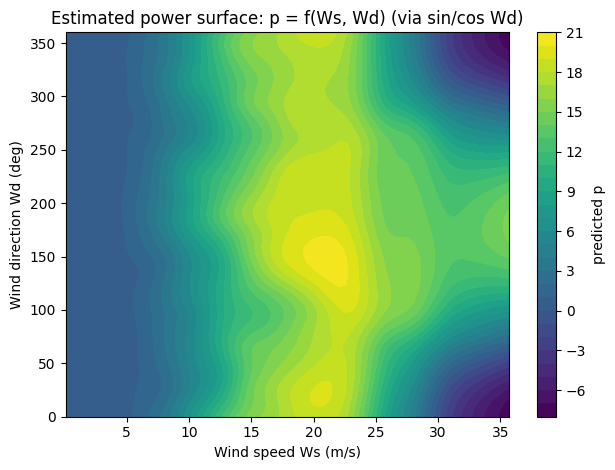

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 网格
ws_grid = np.linspace(Ws.min(), Ws.max(), 80)
wd_grid = np.linspace(0, 360, 121)
WS, WD = np.meshgrid(ws_grid, wd_grid)

# 转成 sin/cos
ang = (WD % 360.0) * np.pi / 180.0
SIN = np.sin(ang)
COS = np.cos(ang)

# 关键：Xg 必须是 3 列
Xg = np.column_stack([WS.ravel(), SIN.ravel(), COS.ravel()])
Pg = gam.predict(Xg).reshape(WD.shape)

plt.figure()
plt.contourf(WS, WD, Pg, levels=30)
plt.xlabel("Wind speed Ws (m/s)")
plt.ylabel("Wind direction Wd (deg)")
plt.title("Estimated power surface: p = f(Ws, Wd) (via sin/cos Wd)")
plt.colorbar(label="predicted p")
plt.tight_layout()
plt.show()
